# Лабораторная работа №4

### Подколодный Артём ИУ10-56

Линейная функция: y = 0.14 * x + 2.36
Степенная функция: y = 0.60 * x^0.72
Показательная функция: y = 1.68 * e^(0.03 * x)
Квадратичная функция: y = -0.00 * x^2 + 0.24 * x + 1.39


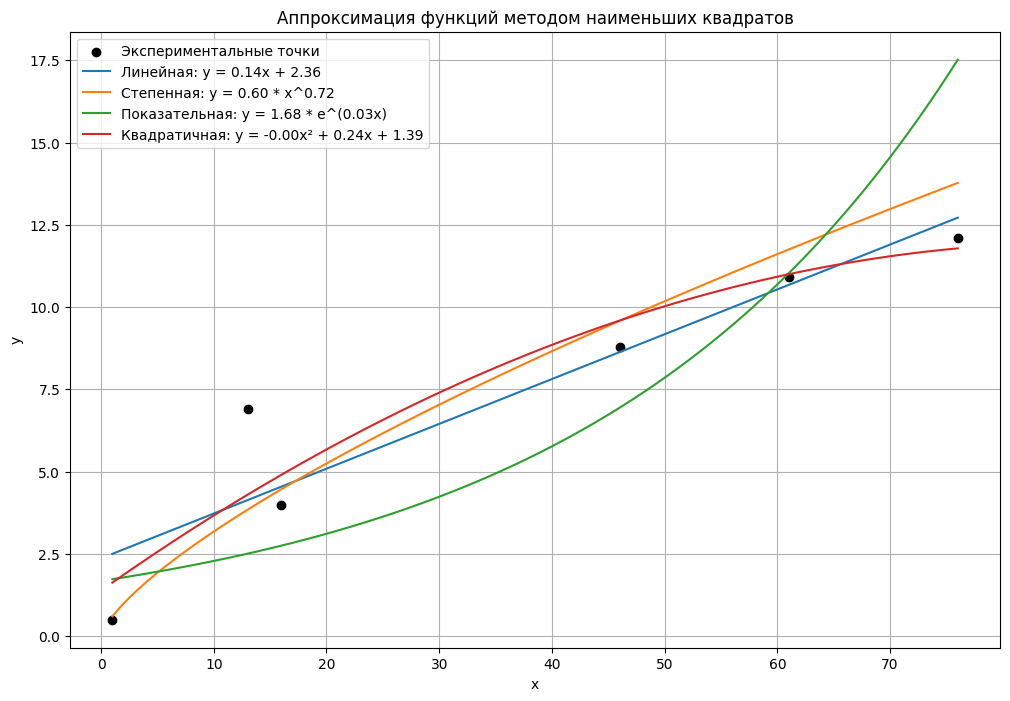


Суммарные погрешности:
Линейная функция: 12.40
Степенная функция: 13.71
Показательная функция: 55.17
Квадратичная функция: 9.59

Лучшая аппроксимирующая функция: Квадратичная с погрешностью 9.59


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, exp

# Данные варианта 13
x = np.array([1, 16, 13, 46, 61, 76])
y = np.array([0.5, 4.0, 6.9, 8.8, 10.9, 12.1])
n = len(x)

# 1.1 Линейная функция y = a*x + b
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_x2 = np.sum(x**2)
sum_xy = np.sum(x * y)

delta = n * sum_x2 - sum_x**2
delta_a = n * sum_xy - sum_x * sum_y
delta_b = sum_x2 * sum_y - sum_x * sum_xy

a_linear = delta_a / delta
b_linear = delta_b / delta
print(f"Линейная функция: y = {a_linear:.2f} * x + {b_linear:.2f}")

# 1.2 Степенная функция y = β * x^a
ln_x = np.log(x)
ln_y = np.log(y)

sum_lnx = np.sum(ln_x)
sum_lny = np.sum(ln_y)
sum_lnx2 = np.sum(ln_x**2)
sum_lnxlny = np.sum(ln_x * ln_y)

delta_power = n * sum_lnx2 - sum_lnx**2
delta_a_power = n * sum_lnxlny - sum_lnx * sum_lny
delta_b_power = sum_lnx2 * sum_lny - sum_lnx * sum_lnxlny

a_power = delta_a_power / delta_power
b_power = delta_b_power / delta_power
beta_power = exp(b_power)
print(f"Степенная функция: y = {beta_power:.2f} * x^{a_power:.2f}")

# 1.3 Показательная функция y = β * e^(a*x)
sum_x_exp = sum_x
sum_x2_exp = sum_x2
sum_lny_exp = sum_lny
sum_xlny = np.sum(x * ln_y)

delta_exp = n * sum_x2_exp - sum_x_exp**2
delta_a_exp = n * sum_xlny - sum_x_exp * sum_lny_exp
delta_b_exp = sum_x2_exp * sum_lny_exp - sum_x_exp * sum_xlny

a_exp = delta_a_exp / delta_exp
b_exp = delta_b_exp / delta_exp
beta_exp = exp(b_exp)
print(f"Показательная функция: y = {beta_exp:.2f} * e^({a_exp:.2f} * x)")

# 1.4 Квадратичная функция y = a*x^2 + b*x + c
sum_x3 = np.sum(x**3)
sum_x4 = np.sum(x**4)
sum_x2y = np.sum(x**2 * y)

A = np.array([
    [sum_x4, sum_x3, sum_x2],
    [sum_x3, sum_x2, sum_x],
    [sum_x2, sum_x, n]
])
B = np.array([sum_x2y, sum_xy, sum_y])
a_quad, b_quad, c_quad = np.linalg.solve(A, B)
print(f"Квадратичная функция: y = {a_quad:.2f} * x^2 + {b_quad:.2f} * x + {c_quad:.2f}")

# 2. Построение графиков
x_smooth = np.linspace(min(x), max(x), 100)
y_linear = a_linear * x_smooth + b_linear
y_power = beta_power * x_smooth ** a_power
y_exp = beta_exp * np.exp(a_exp * x_smooth)
y_quad = a_quad * x_smooth**2 + b_quad * x_smooth + c_quad

plt.figure(figsize=(12, 8))
plt.scatter(x, y, color='black', label='Экспериментальные точки')
plt.plot(x_smooth, y_linear, label=f'Линейная: y = {a_linear:.2f}x + {b_linear:.2f}')
plt.plot(x_smooth, y_power, label=f'Степенная: y = {beta_power:.2f} * x^{a_power:.2f}')
plt.plot(x_smooth, y_exp, label=f'Показательная: y = {beta_exp:.2f} * e^({a_exp:.2f}x)')
plt.plot(x_smooth, y_quad, label=f'Квадратичная: y = {a_quad:.2f}x² + {b_quad:.2f}x + {c_quad:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.title('Аппроксимация функций методом наименьших квадратов')
plt.show()

# 3. Сравнение погрешностей
y_linear_vals = a_linear * x + b_linear
y_power_vals = beta_power * x ** a_power
y_exp_vals = beta_exp * np.exp(a_exp * x)
y_quad_vals = a_quad * x**2 + b_quad * x + c_quad

L_linear = np.sum((y_linear_vals - y)**2)
L_power = np.sum((y_power_vals - y)**2)
L_exp = np.sum((y_exp_vals - y)**2)
L_quad = np.sum((y_quad_vals - y)**2)

print(f"\nСуммарные погрешности:")
print(f"Линейная функция: {L_linear:.2f}")
print(f"Степенная функция: {L_power:.2f}")
print(f"Показательная функция: {L_exp:.2f}")
print(f"Квадратичная функция: {L_quad:.2f}")

# Определение лучшей функции
errors = {
    'Линейная': L_linear,
    'Степенная': L_power,
    'Показательная': L_exp,
    'Квадратичная': L_quad
}
best_func = min(errors, key=errors.get)
print(f"\nЛучшая аппроксимирующая функция: {best_func} с погрешностью {errors[best_func]:.2f}")

РЕЗУЛЬТАТЫ МНК (вариант 13)

Линейная:      y = 0.15x + 1.29
Степенная:     y = 0.51 * x^0.75
Показательная: y = 1.23 * e^(0.0365x)
Квадратичная:  y = -0.0012x² + 0.2434x + 0.3257

Сумма квадратов отклонений:
Линейная: 2.6749
Степенная: 0.5643
Показательная: 77.1184
Квадратичная: 0.1024


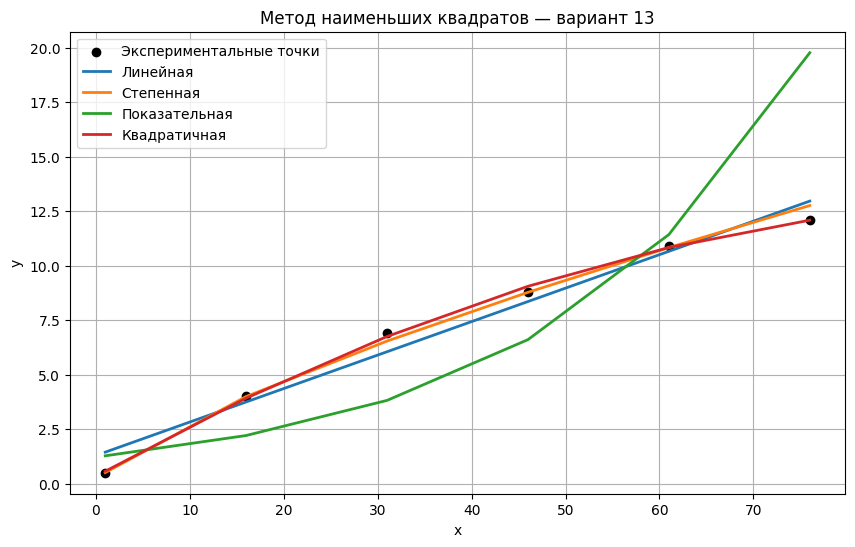

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Данные для варианта 13
x = np.array([1, 16, 31, 46, 61, 76], dtype=float)
y = np.array([0.5, 4.0, 6.9, 8.8, 10.9, 12.1], dtype=float)
n = len(x)

# ----------------------------------------
# 1. ЛИНЕЙНАЯ АППРОКСИМАЦИЯ: y = a*x + b
# ----------------------------------------
sx = np.sum(x)
sy = np.sum(y)
sxx = np.sum(x**2)
sxy = np.sum(x*y)

a_lin = (n*sxy - sx*sy) / (n*sxx - sx**2)
b_lin = (sy - a_lin*sx) / n

y_lin = a_lin * x + b_lin

# ----------------------------------------
# 2. СТЕПЕННАЯ АППРОКСИМАЦИЯ: y = β*x^a
# ----------------------------------------
X = np.log(x)
Y = np.log(y)
sX = np.sum(X)
sY = np.sum(Y)
sXX = np.sum(X**2)
sXY = np.sum(X*Y)

a_pow = (n*sXY - sX*sY) / (n*sXX - sX**2)
b_pow = (sY - a_pow*sX) / n
beta_pow = np.exp(b_pow)

y_pow = beta_pow * x**a_pow

# ----------------------------------------
# 3. ПОКАЗАТЕЛЬНАЯ АППРОКСИМАЦИЯ: y = β*e^(a*x)
# ----------------------------------------
Y = np.log(y)
sxy_exp = np.sum(x*Y)
sy_exp = np.sum(Y)
a_exp = (n*sxy_exp - sx*sy_exp) / (n*sxx - sx**2)
b_exp = (sy_exp - a_exp*sx) / n
beta_exp = np.exp(b_exp)

y_exp = beta_exp * np.exp(a_exp * x)

# ----------------------------------------
# 4. КВАДРАТИЧНАЯ АППРОКСИМАЦИЯ: y = a*x² + b*x + c
# ----------------------------------------
s3 = np.sum(x**3)
s4 = np.sum(x**4)
sxx = np.sum(x**2)
sxy = np.sum(x*y)
sx2y = np.sum(x**2 * y)

A = np.array([[s4, s3, sxx],
              [s3, sxx, sx],
              [sxx, sx, n]])
B = np.array([sx2y, sxy, sy])

a_quad, b_quad, c_quad = np.linalg.solve(A, B)
y_quad = a_quad*x**2 + b_quad*x + c_quad

# ----------------------------------------
# Суммы квадратов ошибок
# ----------------------------------------
def mse(y_true, y_pred):
    return np.sum((y_true - y_pred)**2)

errors = {
    "Линейная": mse(y, y_lin),
    "Степенная": mse(y, y_pow),
    "Показательная": mse(y, y_exp),
    "Квадратичная": mse(y, y_quad)
}

# ----------------------------------------
# РЕЗУЛЬТАТЫ
# ----------------------------------------
print("РЕЗУЛЬТАТЫ МНК (вариант 13)\n")
print(f"Линейная:      y = {a_lin:.2f}x + {b_lin:.2f}")
print(f"Степенная:     y = {beta_pow:.2f} * x^{a_pow:.2f}")
print(f"Показательная: y = {beta_exp:.2f} * e^({a_exp:.4f}x)")
print(f"Квадратичная:  y = {a_quad:.4f}x² + {b_quad:.4f}x + {c_quad:.4f}\n")
print("Сумма квадратов отклонений:")
for name, err in errors.items():
    print(f"{name}: {err:.4f}")

# ----------------------------------------
# ГРАФИКИ
# ----------------------------------------
plt.figure(figsize=(10,6))
plt.scatter(x, y, color='black', label='Экспериментальные точки')
plt.plot(x, y_lin, label='Линейная', lw=2)
plt.plot(x, y_pow, label='Степенная', lw=2)
plt.plot(x, y_exp, label='Показательная', lw=2)
plt.plot(x, y_quad, label='Квадратичная', lw=2)
plt.legend()
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Метод наименьших квадратов — вариант 13')
plt.show()
